# Démo : Analyse d'erreur de bout en bout (dataset : Bike Sharing)

Ce notebook illustre une **analyse d'erreur complète** sur un problème de régression réel.

**Dataset :** [Bike Sharing Dataset (UCI)](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset) — prédiction du nombre de locations de vélos par heure.

**Plan :**
1. Chargement & exploration des données
2. Preprocessing & pipeline
3. Analyse des paramètres d'une régression linéaire
4. Modèle plus performant (Gradient Boosting)
5. Analyse des résidus
6. Importance des features (intégrée + permutation)
7. Interprétation locale avec LIME
8. Interprétation globale et locale avec SHAP
9. Synthèse comparative

## 0. Imports & setup

In [10]:
import warnings
warnings.filterwarnings('ignore')

import io, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100



## 1. Chargement du dataset Bike Sharing

Le dataset contient les données horaires de location de vélos en libre-service à Washington D.C. (2011–2012).  
**Variable cible :** `cnt` = nombre total de locations par heure (= `casual` + `registered`).

| Feature | Description |
|---------|-------------|
| `season` | 1=printemps, 2=été, 3=automne, 4=hiver |
| `yr` | Année (0=2011, 1=2012) |
| `mnth` | Mois (1–12) |
| `hr` | Heure de la journée (0–23) |
| `holiday` | Jour férié |
| `weekday` | Jour de la semaine |
| `workingday` | Jour ouvré |
| `weathersit` | Situation météo (1=clair, 2=nuageux, 3=pluie légère, 4=pluie forte) |
| `temp` | Température normalisée |
| `atemp` | Température ressentie normalisée |
| `hum` | Humidité normalisée |
| `windspeed` | Vitesse du vent normalisée |

In [11]:
# Téléchargement du dataset depuis l'UCI ML Repository
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'

try:
    response = urllib.request.urlopen(URL, timeout=15)
    zf = zipfile.ZipFile(io.BytesIO(response.read()))
    df_raw = pd.read_csv(zf.open('hour.csv'))
    print(f'Dataset chargé depuis UCI : {df_raw.shape[0]:,} lignes, {df_raw.shape[1]} colonnes')
except Exception as e:
    print(f'Erreur de téléchargement ({e}), tentative depuis un fichier local...')
    df_raw = pd.read_csv('hour.csv')

df_raw.head(3)

Dataset chargé depuis UCI : 17,379 lignes, 17 colonnes


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


## 2. Exploration des données (EDA)

In [12]:
# Sélection des features utiles
cat_features  = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
num_features  = ['temp', 'atemp', 'hum', 'windspeed']
target        = 'cnt'

df = df_raw[cat_features + num_features + [target]].copy()

print('Shape :', df.shape)
print('\nValeurs manquantes :', df.isnull().sum().sum())
print('\nStatistiques de la cible :')
print(df[target].describe().round(1))

Shape : (17379, 13)

Valeurs manquantes : 0

Statistiques de la cible :
count    17379.0
mean       189.5
std        181.4
min          1.0
25%         40.0
50%        142.0
75%        281.0
max        977.0
Name: cnt, dtype: float64


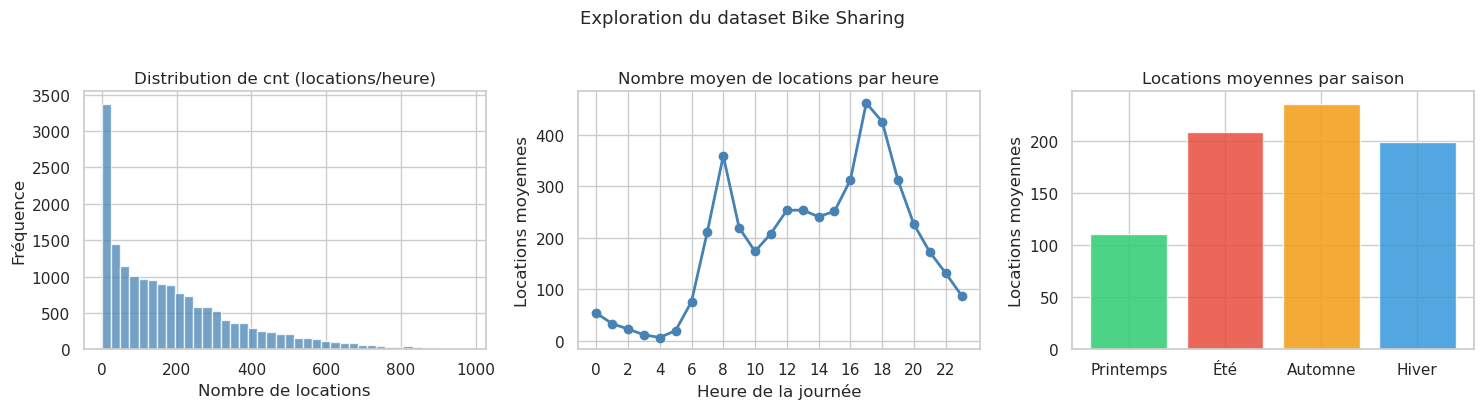

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la variable cible
axes[0].hist(df['cnt'], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_title('Distribution de cnt (locations/heure)')
axes[0].set_xlabel('Nombre de locations')
axes[0].set_ylabel('Fréquence')

# Locations par heure (profil journalier)
hourly = df.groupby('hr')['cnt'].mean()
axes[1].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Nombre moyen de locations par heure')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Locations moyennes')
axes[1].set_xticks(range(0, 24, 2))

# Locations par saison
season_map = {1: 'Printemps', 2: 'Été', 3: 'Automne', 4: 'Hiver'}
seasonal = df.groupby('season')['cnt'].mean()
axes[2].bar([season_map[s] for s in seasonal.index], seasonal.values,
            color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'], alpha=0.85)
axes[2].set_title('Locations moyennes par saison')
axes[2].set_ylabel('Locations moyennes')

plt.suptitle('Exploration du dataset Bike Sharing', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

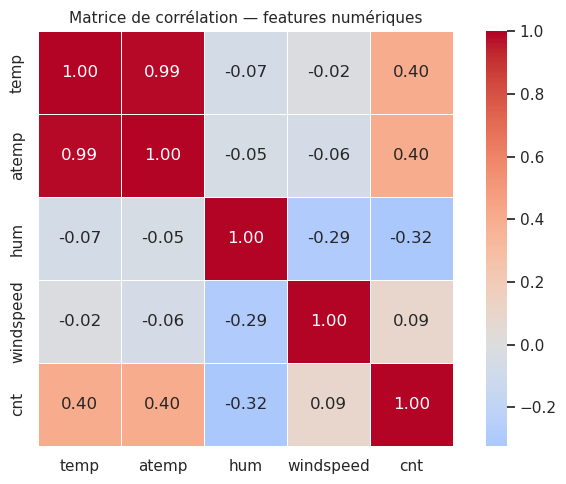

In [14]:
# Matrice de corrélation des features numériques + cible
corr_cols = num_features + [target]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélation — features numériques', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Preprocessing & pipeline

On construit un pipeline sklearn :
- `StandardScaler` pour les features numériques continues
- `OneHotEncoder` pour les features catégorielles (heure, saison, mois…)

In [15]:
X = df[cat_features + num_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])

print(f'Train : {X_train.shape[0]:,} observations')
print(f'Test  : {X_test.shape[0]:,} observations')

Train : 13,903 observations
Test  : 3,476 observations


## 4. Analyse des paramètres d'une régression linéaire

La régression linéaire est le point de départ naturel pour tout problème de régression : ses **coefficients sont directement interprétables** (signe, magnitude). On compare également avec la régression Ridge (L2) qui réduit le surajustement.

In [16]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Modèle' : name,
        'R²'     : r2_score(y_te, y_pred),
        'MAE'    : mean_absolute_error(y_te, y_pred),
        'RMSE'   : np.sqrt(mean_squared_error(y_te, y_pred)),
    }

# Pipeline LinearRegression
pipe_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
pipe_ridge = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=10.0))])

results = []
results.append(evaluate('LinearRegression', pipe_lr, X_train, y_train, X_test, y_test))
results.append(evaluate('Ridge (α=10)', pipe_ridge, X_train, y_train, X_test, y_test))

pd.DataFrame(results).set_index('Modèle').round(3)

,R²,MAE,RMSE
Modèle,,,
LinearRegression,0.681,74.105,100.446
Ridge (α=10),0.682,74.058,100.373


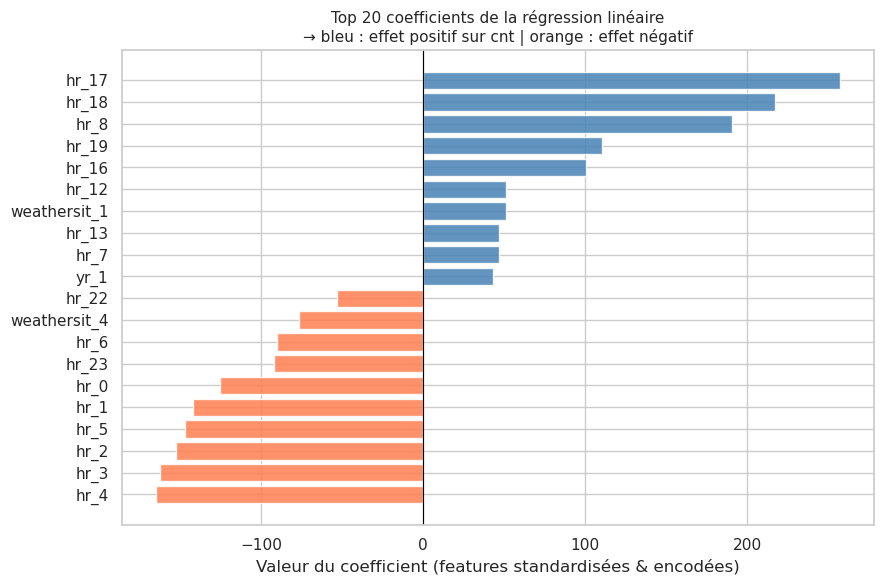


Interprétation (features numériques — standardisées) :
  temp         : +21.8  →  un écart-type de plus = +21.8 locations/h
  atemp        : +21.3  →  un écart-type de plus = +21.3 locations/h
  hum          : -15.8  →  un écart-type de plus = -15.8 locations/h
  windspeed    : -3.8  →  un écart-type de plus = -3.8 locations/h


In [17]:
# Récupérer les noms de features après transformation
pipe_lr.fit(X_train, y_train)   # s'assurer que le pipeline est ajusté
num_names = num_features
cat_names = list(pipe_lr.named_steps['prep']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_features))
all_feature_names = num_names + cat_names

coefs = pipe_lr.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': all_feature_names, 'coeff': coefs})

# Afficher uniquement les features numériques + quelques catégorielles importantes
# (on garde les 20 valeurs absolues les plus grandes)
top_coef = coef_df.reindex(coef_df['coeff'].abs().nlargest(20).index).sort_values('coeff')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['coral' if c < 0 else 'steelblue' for c in top_coef['coeff']]
ax.barh(top_coef['feature'], top_coef['coeff'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 coefficients de la régression linéaire\n'
             '→ bleu : effet positif sur cnt | orange : effet négatif', fontsize=11)
ax.set_xlabel('Valeur du coefficient (features standardisées & encodées)')
plt.tight_layout()
plt.show()

print('\nInterprétation (features numériques — standardisées) :')
for _, row in coef_df[coef_df['feature'].isin(num_features)].iterrows():
    signe = '+' if row['coeff'] > 0 else ''
    print(f"  {row['feature']:12s} : {signe}{row['coeff']:.1f}  →  un écart-type de plus = {signe}{row['coeff']:.1f} locations/h")

## 5. Modèle plus performant : Gradient Boosting

Un modèle non linéaire capture mieux les interactions (ex : l'heure de pointe le matin n'est pas la même l'hiver qu'en été).

In [18]:
pipe_gbm = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.1,
        max_depth=5, random_state=42
    ))
])

results.append(evaluate('GradientBoosting', pipe_gbm, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).set_index('Modèle').round(3)
print(results_df)

# S'assurer que le pipeline GBM est bien ajusté pour la suite
pipe_gbm.fit(X_train, y_train)
y_pred_gbm = pipe_gbm.predict(X_test)

                     R²     MAE     RMSE
Modèle                                  
LinearRegression  0.681  74.105  100.446
Ridge (α=10)      0.682  74.058  100.373
GradientBoosting  0.932  30.299   46.439


## 6. Analyse des résidus

Même avec un modèle performant, analyser les résidus permet d'identifier :
- des **biais systématiques** (sur-estimation ou sous-estimation pour certaines plages de valeurs)
- des **violations d'hypothèses** statistiques (hétéroscédasticité, non-normalité)
- les **patterns temporels** non capturés (ex : heure, jour de la semaine)

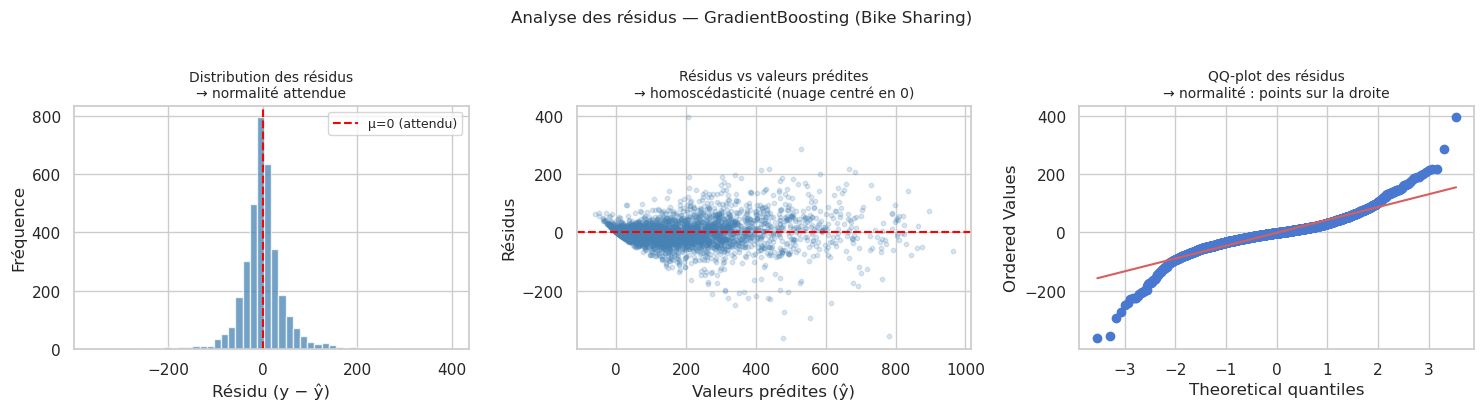

Moyenne des résidus : -1.057  (attendu : ≈ 0)
Médiane des résidus : -1.637


In [19]:
residuals = y_test.values - y_pred_gbm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution des résidus
axes[0].hist(residuals, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='μ=0 (attendu)')
axes[0].set_title('Distribution des résidus\n→ normalité attendue', fontsize=10)
axes[0].set_xlabel('Résidu (y − ŷ)')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=9)

# 2. Résidus vs valeurs prédites (homoscédasticité)
axes[1].scatter(y_pred_gbm, residuals, alpha=0.2, color='steelblue', s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Résidus vs valeurs prédites\n→ homoscédasticité (nuage centré en 0)', fontsize=10)
axes[1].set_xlabel('Valeurs prédites (ŷ)')
axes[1].set_ylabel('Résidus')

# 3. QQ-plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot des résidus\n→ normalité : points sur la droite', fontsize=10)

plt.suptitle('Analyse des résidus — GradientBoosting (Bike Sharing)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Moyenne des résidus : {residuals.mean():.3f}  (attendu : ≈ 0)')
print(f'Médiane des résidus : {np.median(residuals):.3f}')

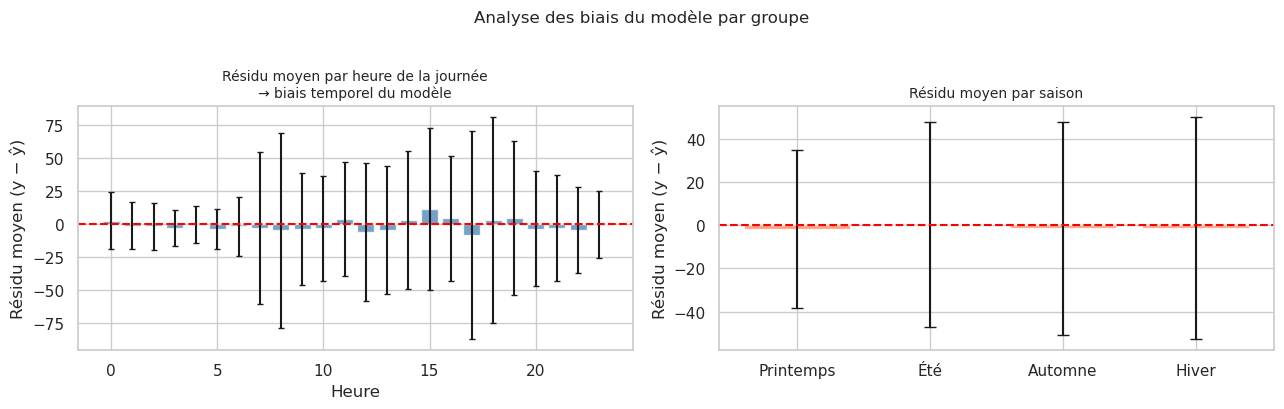

In [20]:
# Résidus par heure de la journée — détecter des biais temporels
df_res = X_test.copy()
df_res['residual'] = residuals
df_res['y_pred']   = y_pred_gbm
df_res['y_true']   = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Résidus par heure
hourly_res = df_res.groupby('hr')['residual'].agg(['mean', 'std'])
axes[0].bar(hourly_res.index, hourly_res['mean'],
            yerr=hourly_res['std'], color='steelblue', alpha=0.75, capsize=2)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Résidu moyen par heure de la journée\n→ biais temporel du modèle', fontsize=10)
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Résidu moyen (y − ŷ)')

# Résidus par saison
season_res = df_res.groupby('season')['residual'].agg(['mean', 'std'])
season_res.index = [season_map[s] for s in season_res.index]
axes[1].bar(season_res.index, season_res['mean'],
            yerr=season_res['std'], color='coral', alpha=0.75, capsize=4)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Résidu moyen par saison', fontsize=10)
axes[1].set_ylabel('Résidu moyen (y − ŷ)')

plt.suptitle('Analyse des biais du modèle par groupe', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 7. Importance des features

Deux méthodes complémentaires :
- **Feature importances intégrées** (`feature_importances_`) : rapide, basées sur la réduction d'impureté dans les arbres. Peut surestimer les features continues à haute cardinalité.
- **Permutation importance** : plus robuste, agnostique au modèle — mesure la vraie dégradation de performance.

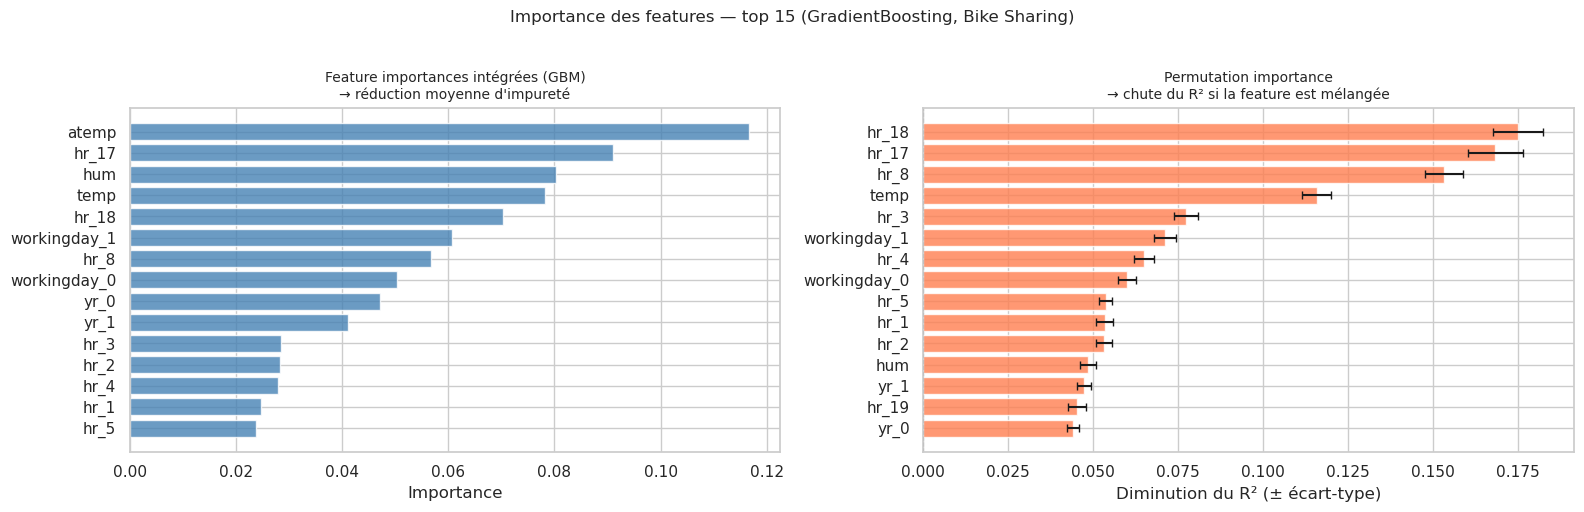

In [21]:
# Noms des features après transformation
cat_names_all = list(pipe_gbm.named_steps['prep']
                              .named_transformers_['cat']
                              .get_feature_names_out(cat_features))
all_names = num_features + cat_names_all

gbm_model = pipe_gbm.named_steps['model']
X_test_transformed = pipe_gbm.named_steps['prep'].transform(X_test)

# --- Feature importances intégrées ---
fi_df = pd.DataFrame({
    'feature'   : all_names,
    'importance': gbm_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# --- Permutation importance ---
perm = permutation_importance(
    gbm_model, X_test_transformed, y_test,
    n_repeats=15, random_state=42, scoring='r2'
)
perm_df = pd.DataFrame({
    'feature'        : all_names,
    'importance_mean': perm.importances_mean,
    'importance_std' : perm.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

# --- Visualisation côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Feature importances intégrées (GBM)\n→ réduction moyenne d\'impureté', fontsize=10)
axes[0].set_xlabel('Importance')

axes[1].barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
             xerr=perm_df['importance_std'][::-1],
             color='coral', alpha=0.8, edgecolor='white', capsize=3)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Permutation importance\n→ chute du R² si la feature est mélangée', fontsize=10)
axes[1].set_xlabel('Diminution du R² (± écart-type)')

plt.suptitle('Importance des features — top 15 (GradientBoosting, Bike Sharing)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Interprétation locale avec LIME

**LIME** (Local Interpretable Model-agnostic Explanations) explique **une prédiction individuelle** en construisant localement un modèle simple (linéaire) autour du point à expliquer.

**Principe :**
1. Générer des perturbations aléatoires autour de l'observation à expliquer
2. Obtenir les prédictions du modèle boîte noire sur ces perturbations
3. Ajuster un modèle linéaire interprétable sur ces prédictions (pondéré par la proximité)
4. Les coefficients de ce modèle local = l'explication LIME

> **Avantage :** fonctionne avec n'importe quel modèle. **Limite :** l'explication est locale et peut varier selon les perturbations.

In [22]:
from lime import lime_tabular

# Préparer les données transformées pour LIME
X_train_transformed = pipe_gbm.named_steps['prep'].transform(X_train)
X_test_transformed  = pipe_gbm.named_steps['prep'].transform(X_test)

# Créer l'explainer LIME
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data   = X_train_transformed,
    feature_names   = all_names,
    mode            = 'regression',
    random_state    = 42
)

# Identifier une prédiction juste et une prédiction avec forte erreur
errors_abs = np.abs(y_test.values - y_pred_gbm)
idx_good = np.argmin(errors_abs)                          # meilleure prédiction
idx_bad  = np.argmax(errors_abs)                          # pire prédiction

print(f"Bonne prédiction  (idx={idx_good}) : y={y_test.values[idx_good]:.0f}, ŷ={y_pred_gbm[idx_good]:.0f}, erreur={errors_abs[idx_good]:.1f}")
print(f"Mauvaise prédiction (idx={idx_bad})  : y={y_test.values[idx_bad]:.0f}, ŷ={y_pred_gbm[idx_bad]:.0f}, erreur={errors_abs[idx_bad]:.1f}")

Bonne prédiction  (idx=1113) : y=318, ŷ=318, erreur=0.0
Mauvaise prédiction (idx=1820)  : y=601, ŷ=204, erreur=396.6


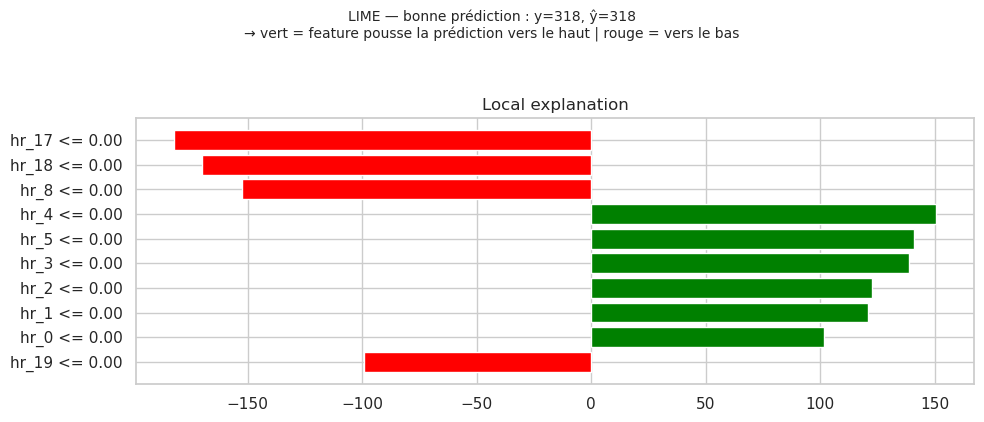

In [23]:
# Explication LIME — bonne prédiction
exp_good = explainer_lime.explain_instance(
    X_test_transformed[idx_good],
    gbm_model.predict,
    num_features=10
)

fig = exp_good.as_pyplot_figure()
fig.set_size_inches(10, 4)
fig.suptitle(
    f'LIME — bonne prédiction : y={y_test.values[idx_good]:.0f}, ŷ={y_pred_gbm[idx_good]:.0f}\n'
    f'→ vert = feature pousse la prédiction vers le haut | rouge = vers le bas',
    fontsize=10, y=1.05
)
plt.tight_layout()
plt.show()

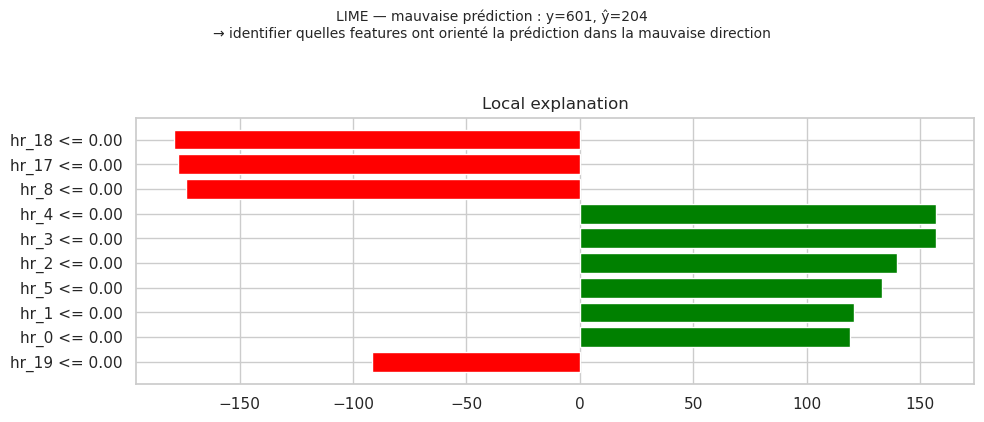

In [24]:
# Explication LIME — mauvaise prédiction
exp_bad = explainer_lime.explain_instance(
    X_test_transformed[idx_bad],
    gbm_model.predict,
    num_features=10
)

fig = exp_bad.as_pyplot_figure()
fig.set_size_inches(10, 4)
fig.suptitle(
    f'LIME — mauvaise prédiction : y={y_test.values[idx_bad]:.0f}, ŷ={y_pred_gbm[idx_bad]:.0f}\n'
    f'→ identifier quelles features ont orienté la prédiction dans la mauvaise direction',
    fontsize=10, y=1.05
)
plt.tight_layout()
plt.show()

## 9. Interprétation avec SHAP

**SHAP** (SHapley Additive exPlanations) est fondé sur la théorie des **valeurs de Shapley** (théorie des jeux coopératifs). Il mesure la contribution marginale de chaque feature en considérant toutes les coalitions possibles.

**Avantages par rapport à LIME :**
- Garanties théoriques (efficience, symétrie, linéarité, dummy player)
- Cohérence locale ET globale (les importances globales = moyenne des valeurs absolues locales)
- Visualisations riches : summary plot, waterfall, dependence plot

**Types de graphiques SHAP :**
| Graphique | Ce qu'il montre |
|-----------|----------------|
| **Summary plot (beeswarm)** | Impact de chaque feature sur l'ensemble du dataset |
| **Waterfall plot** | Décomposition d'une prédiction individuelle |
| **Dependence plot** | Relation entre la valeur d'une feature et son impact SHAP |

In [25]:
import shap

# TreeExplainer est optimisé pour les modèles basés sur des arbres (GBM, RF, XGBoost...)
explainer_shap = shap.TreeExplainer(gbm_model)

# Calcul des valeurs SHAP sur un sous-ensemble du test set (pour la rapidité)
X_shap = X_test_transformed[:500]
shap_values = explainer_shap(X_shap)

print(f'Valeurs SHAP calculées pour {len(X_shap)} observations')
print(f'Shape des valeurs SHAP : {shap_values.values.shape}')

Valeurs SHAP calculées pour 500 observations
Shape des valeurs SHAP : (500, 61)


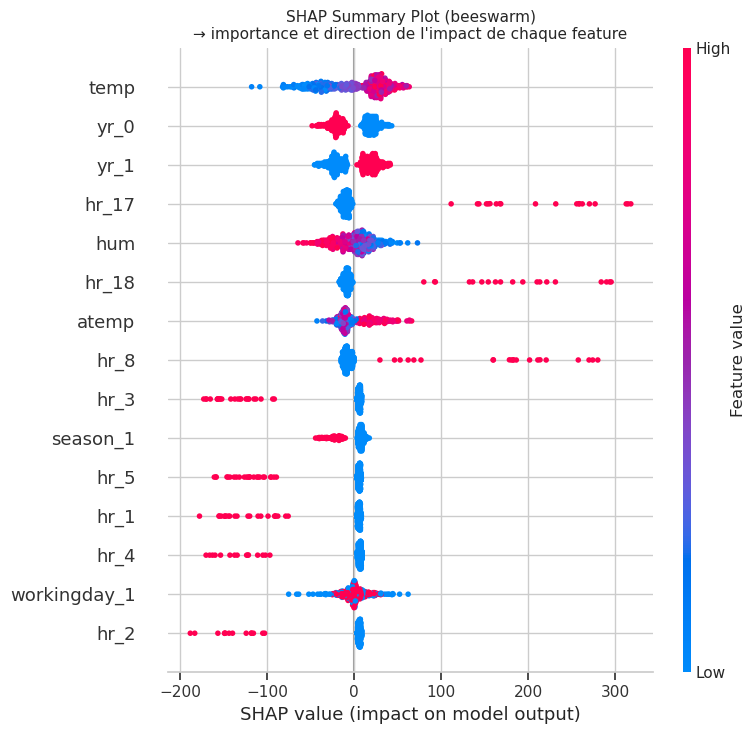

In [26]:
# --- Summary plot (beeswarm) : importance globale ---
# Chaque point = une observation. Couleur = valeur de la feature (rouge=haute, bleu=basse)
# Position horizontale = impact sur la prédiction (+ = augmente cnt, - = diminue cnt)

shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=all_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot (beeswarm)\n→ importance et direction de l\'impact de chaque feature', fontsize=11)
plt.tight_layout()
plt.show()

Observation analysée : y=425, ŷ=416


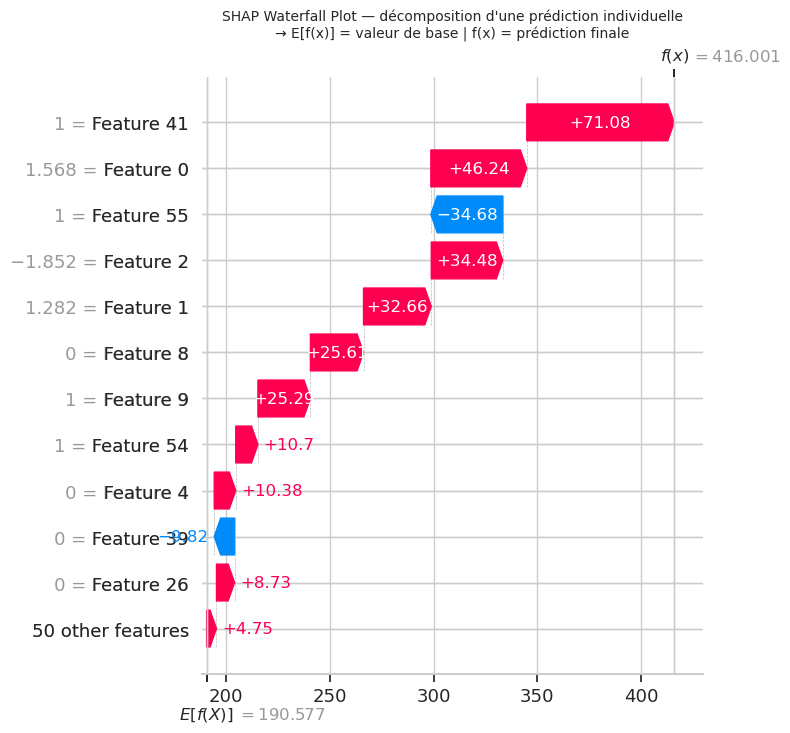

In [27]:
# --- Waterfall plot : décomposition d'une prédiction individuelle ---
# Montre comment chaque feature pousse la prédiction depuis la valeur de base (E[f(x)])
# vers la prédiction finale f(x)

# Utiliser la même observation que pour LIME (bonne prédiction)
obs_idx = idx_good if idx_good < 500 else 0

print(f'Observation analysée : y={y_test.values[obs_idx]:.0f}, ŷ={y_pred_gbm[obs_idx]:.0f}')

shap.waterfall_plot(
    shap_values[obs_idx],
    max_display=12,
    show=False
)
plt.title('SHAP Waterfall Plot — décomposition d\'une prédiction individuelle\n'
          '→ E[f(x)] = valeur de base | f(x) = prédiction finale', fontsize=10)
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 301it [00:41,  5.80it/s]                         


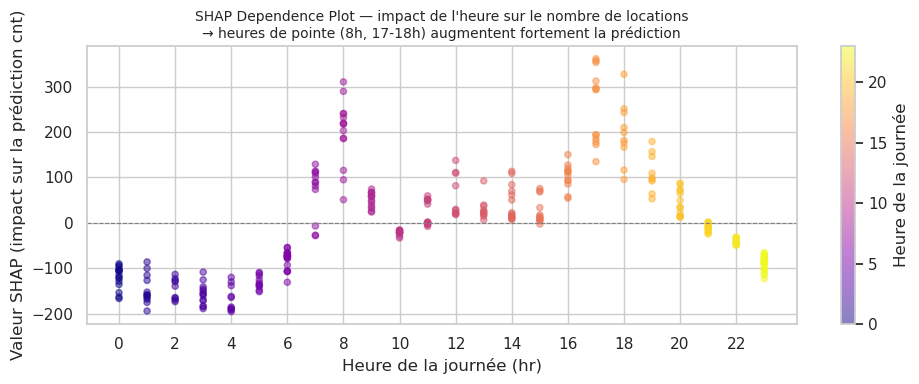

In [28]:
# --- Dependence plot correct : on wrappe le pipeline complet ---
# En passant les données BRUTES (avant OHE) à shap.Explainer, hr reste une feature unique.
# SHAP ne voit plus 24 dummies mais 1 seule variable → pas de problème de cancellation.

X_raw_sample = X_test.reset_index(drop=True).iloc[:300]
background   = X_train.sample(150, random_state=42)

# shap.Explainer détecte automatiquement le bon algorithme (PermutationExplainer ici)
explainer_pipeline = shap.Explainer(pipe_gbm.predict, background)
shap_raw = explainer_pipeline(X_raw_sample)

# hr est la 4ème colonne dans X (index 3)
hr_col_idx = list(X_raw_sample.columns).index('hr')
hr_shap    = shap_raw.values[:, hr_col_idx]
hr_values  = X_raw_sample['hr'].values

fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(hr_values, hr_shap, c=hr_values, cmap='plasma', alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label='Heure de la journée')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Heure de la journée (hr)')
ax.set_ylabel('Valeur SHAP (impact sur la prédiction cnt)')
ax.set_title('SHAP Dependence Plot — impact de l\'heure sur le nombre de locations\n'
             '→ heures de pointe (8h, 17-18h) augmentent fortement la prédiction', fontsize=10)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## 10. Synthèse comparative

### Récapitulatif des méthodes d'interprétation

| Méthode | Portée | Modèle-agnostique | Ce qu'elle répond |
|---------|--------|-------------------|-------------------|
| **Coefficients de régression** | Globale | Non (linéaire uniquement) | Quel est l'effet marginal de chaque feature ? |
| **Feature importances (GBM)** | Globale | Non (arbres uniquement) | Quelles features sont les plus utilisées dans les arbres ? |
| **Permutation importance** | Globale | Oui | Quelle dégradation de performance si on retire une feature ? |
| **LIME** | Locale | Oui | Pourquoi **cette** prédiction individuelle a-t-elle cette valeur ? |
| **SHAP** | Locale + Globale | Partiel (TreeSHAP = spécialisé) | Quelle est la contribution exacte de chaque feature à **cette** prédiction (et en moyenne) ? |

### Conseils d'usage

- Commencer par les **coefficients ou feature importances** pour une vue globale rapide
- Utiliser la **permutation importance** pour valider de manière fiable (évite les artefacts des importances basées sur l'impureté)
- Utiliser **SHAP** pour une analyse complète : il fournit à la fois une vue globale (summary plot) et locale (waterfall) avec des garanties théoriques solides
- Utiliser **LIME** quand SHAP n'est pas disponible ou trop coûteux, ou pour une vérification rapide d'une prédiction suspecte
- **Toujours croiser** les insights des différentes méthodes : si LIME et SHAP désignent la même feature comme déterminante, c'est un signal fort

## 10. Synthèse comparative

### Récapitulatif des méthodes d'interprétation

| Méthode | Portée | Modèle-agnostique | Ce qu'elle répond |
|---------|--------|-------------------|-------------------|
| **Coefficients de régression** | Globale | Non (linéaire uniquement) | Quel est l'effet marginal de chaque feature ? |
| **Feature importances (GBM)** | Globale | Non (arbres uniquement) | Quelles features sont les plus utilisées dans les arbres ? |
| **Permutation importance** | Globale | Oui | Quelle dégradation de performance si on retire une feature ? |
| **LIME** | Locale | Oui | Pourquoi **cette** prédiction individuelle a-t-elle cette valeur ? |
| **SHAP** | Locale + Globale | Partiel (TreeSHAP = spécialisé) | Quelle est la contribution exacte de chaque feature à **cette** prédiction (et en moyenne) ? |

### Conseils d'usage

- Commencer par les **coefficients ou feature importances** pour une vue globale rapide
- Utiliser la **permutation importance** pour valider de manière fiable (évite les artefacts des importances basées sur l'impureté)
- Utiliser **SHAP** pour une analyse complète : il fournit à la fois une vue globale (summary plot) et locale (waterfall) avec des garanties théoriques solides
- Utiliser **LIME** quand SHAP n'est pas disponible ou trop coûteux, ou pour une vérification rapide d'une prédiction suspecte
- **Toujours croiser** les insights des différentes méthodes : si LIME et SHAP désignent la même feature comme déterminante, c'est un signal fort

## Sources
- [Documentation LIME](https://lime-ml.readthedocs.io/en/latest/)
- [Documentation SHAP](https://shap.readthedocs.io/en/latest/)
- [Bike Sharing Dataset — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset)
- [Interpretable Machine Learning — Christoph Molnar (livre open source)](https://christophm.github.io/interpretable-ml-book/)